# Economic News Analysis - Exploratory Data Analysis (EDA)
**Project:** Economic News NLP Dashboard  
**Author:** Miguel Trujillo  
**Date:** January 2026  

This notebook explores the raw data ingested from GDELT. The goal is to understand the media landscape, 
identify key economic topics, and prepare the data for Sentiment Analysis.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

processed_path = "../data/processed/"
latest_file = max([os.path.join(processed_path, f) for f in os.listdir(processed_path)], key=os.path.getctime)
df = pd.read_csv(latest_file)

print(f"Dataset loaded: {len(df)} articles")
df.head()

Dataset loaded: 196 articles


,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry,clean_title,source_name
0,https://www.investopedia.com/terms/f/forward-g...,NaN,Understanding Forward Guidance in Monetary Policy,20260110T104500Z,https://www.investopedia.com/thmb/HLnt5KUHWmGo...,investopedia.com,English,United States,understanding forward guidance in monetary policy,investopedia.com
1,https://www.fxstreet.com/news/eur-usd-steadies...,https://www.fxstreet.com/amp/news/eur-usd-stea...,EUR / USD steadies near 1 . 1650 ahead of US N...,20260109T034500Z,https://editorial.fxsstatic.com/images/i/EURUS...,fxstreet.com,English,China,eur usd steadies near 1 1650 ahead of us non...,fxstreet.com
2,https://www.fxstreet.com/news/eur-usd-slips-to...,https://www.fxstreet.com/amp/news/eur-usd-slip...,EUR / USD slips to 1 . 1600 as firm US data da...,20260119T010000Z,https://editorial.fxsstatic.com/images/i/EURUS...,fxstreet.com,English,China,eur usd slips to 1 1600 as firm us data damp...,fxstreet.com
3,https://www.fxstreet.com/news/eur-usd-edges-ab...,https://www.fxstreet.com/amp/news/eur-usd-edge...,EUR / USD edges above 1 . 1750 due to ECB - Fe...,20260102T044500Z,https://editorial.fxsstatic.com/images/i/EURUS...,fxstreet.com,English,China,eur usd edges above 1 1750 due to ecb fed p...,fxstreet.com
4,https://www.lemonde.fr/en/opinion/article/2026...,NaN,Macron should not target the European Central ...,20260124T020000Z,https://img.lemde.fr/2026/01/21/0/0/7762/5175/...,lemonde.fr,English,France,macron should not target the european central ...,lemonde.fr


C:\Users\Mikel\AppData\Local\Temp\ipykernel_8248\4005464267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")


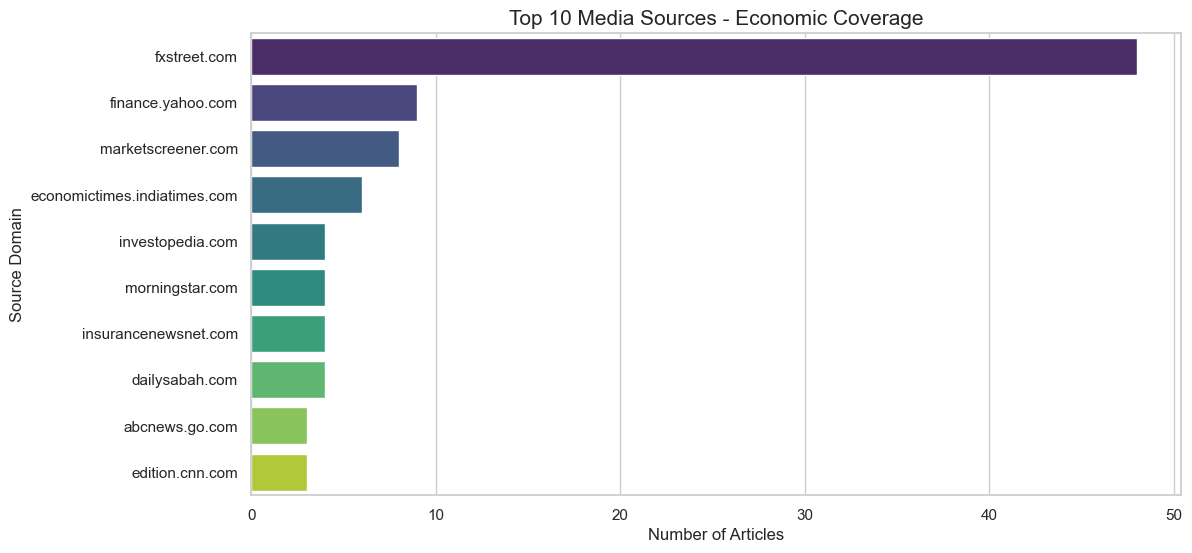

In [15]:
top_sources = df['source_name'].value_counts().head(10)

sns.barplot(x=top_sources.values, y=top_sources.index, palette="viridis")
plt.title("Top 10 Media Sources - Economic Coverage", fontsize=15)
plt.xlabel("Number of Articles")
plt.ylabel("Source Domain")
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mikel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


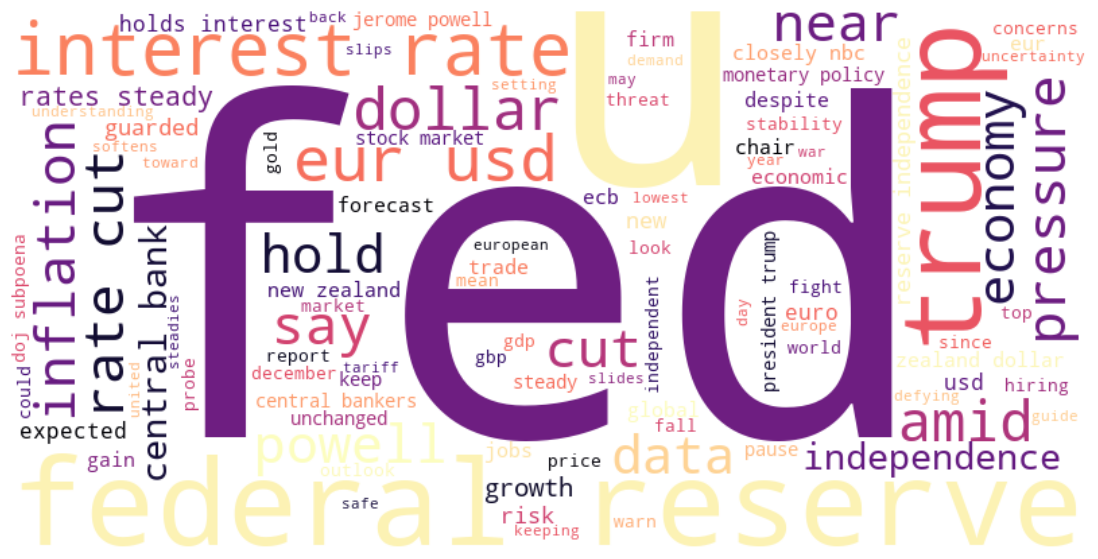

In [16]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english')).union(set(stopwords.words('spanish')))
text = " ".join(title for title in df.clean_title)


wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    stopwords=stop_words, 
    colormap='magma', 
    max_words=100
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

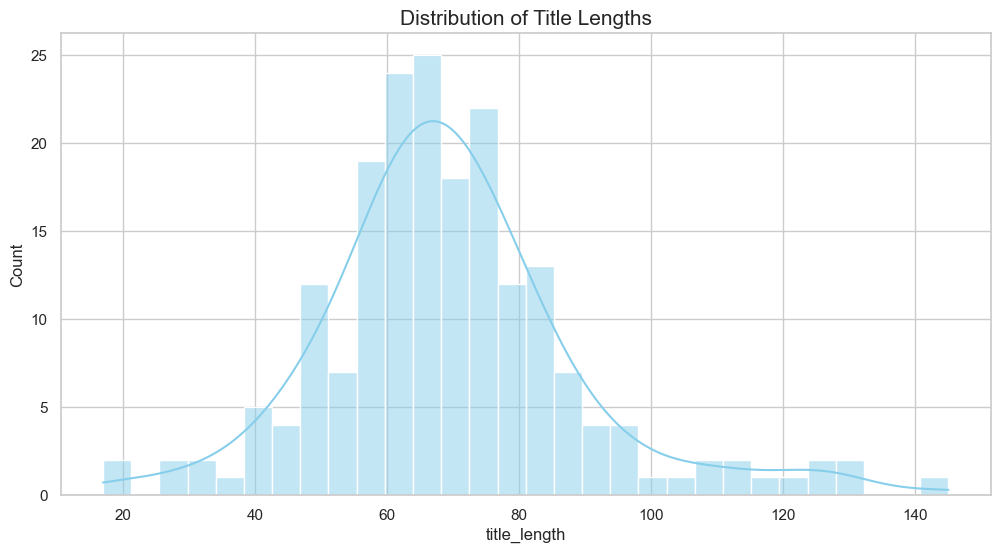

In [17]:
df['title_length'] = df['clean_title'].apply(len)
sns.histplot(df['title_length'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Title Lengths", fontsize=15)
plt.show()

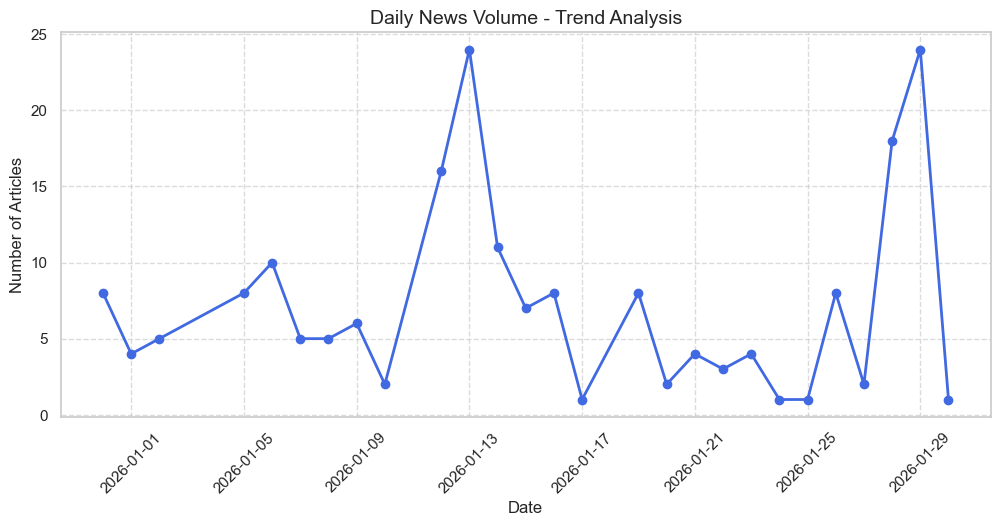

In [20]:
# --- TIME SERIES ANALYSIS (UPDATED) ---

# 1. Convert to datetime using ISO8601 format
df['datetime'] = pd.to_datetime(df['seendate'], format='ISO8601')

# 2. Plotting article volume by DAY (What you are looking for)
plt.figure(figsize=(12, 5))
# We use .dt.date to group strictly by day and count occurrences
df_daily = df['datetime'].dt.date.value_counts().sort_index()

df_daily.plot(kind='line', marker='o', color='royalblue', linewidth=2)
plt.title("Daily News Volume - Trend Analysis", fontsize=14)
plt.ylabel("Number of Articles")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\Mikel\AppData\Local\Temp\ipykernel_8248\258552856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette="rocket")


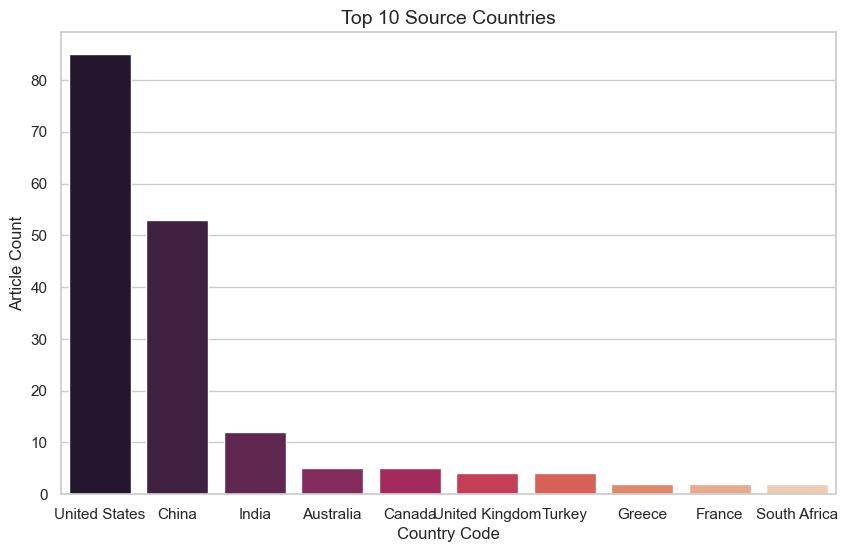

In [21]:
# --- GEOGRAPHIC DISTRIBUTION ---

# Top countries contributing to the news feed
top_countries = df['sourcecountry'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette="rocket")
plt.title("Top 10 Source Countries", fontsize=14)
plt.xlabel("Country Code")
plt.ylabel("Article Count")
plt.show()